<a href="https://colab.research.google.com/github/esraamosalman22-arch/activity-3/blob/main/activity_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

** Load Iris dataset**

In [ ]:

iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2




**Preprocessing**



In [ ]:

print(df.isnull().sum())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64


**PCA**

In [ ]:

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(
"Variance Retained:",
sum(pca.explained_variance_ratio_)
)

Variance Retained: 0.9581320720000166


** PCA Plot**

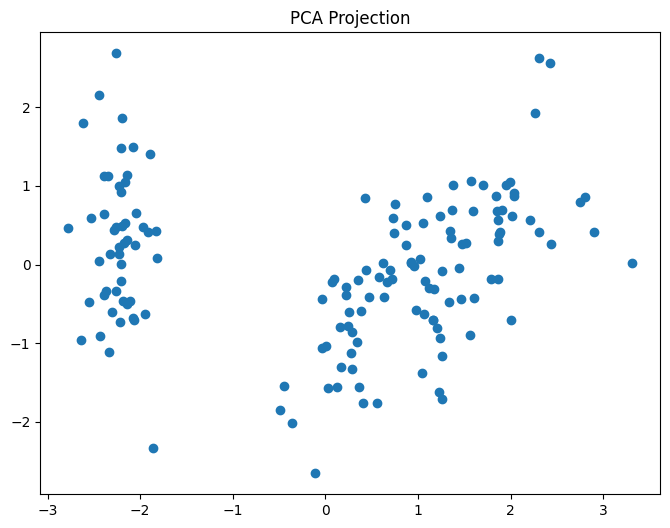

In [ ]:

plt.figure(figsize=(8,6))

plt.scatter(
X_pca[:,0],
X_pca[:,1]
)

plt.title("PCA Projection")
plt.show()




**DBSCAN Original**


In [ ]:
db_original=DBSCAN(
eps=1.1,
min_samples=5
)

labels_original=db_original.fit_predict(
X_scaled
)

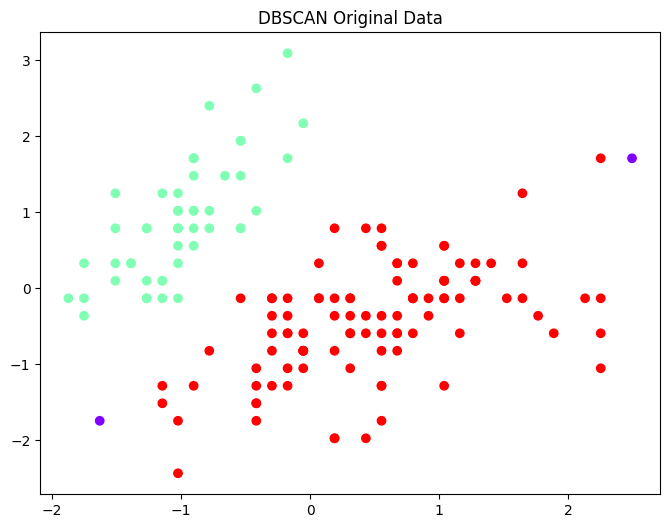

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
X_scaled[:,0],
X_scaled[:,1],
c=labels_original,
cmap="rainbow"
)

plt.title(
"DBSCAN Original Data"
)

plt.show()

 **DBSCAN after PCA**

In [ ]:

db_pca=DBSCAN(
eps=0.8,
min_samples=5
)

labels_pca=db_pca.fit_predict(
X_pca
)

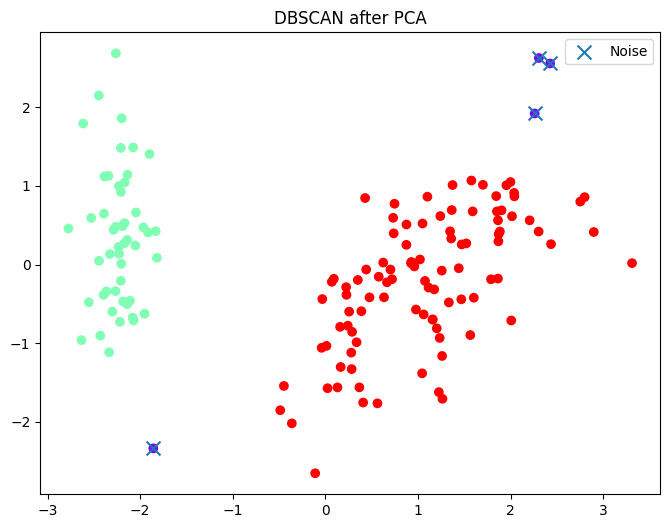

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
X_pca[:,0],
X_pca[:,1],
c=labels_pca,
cmap='rainbow'
)

noise=(labels_pca==-1)

plt.scatter(
X_pca[noise,0],
X_pca[noise,1],
marker='x',
s=100,
label='Noise'
)

plt.legend()
plt.title("DBSCAN after PCA")
plt.show()

In [ ]:
def analyze(labels,name):

    clusters=len(
        set(labels)
    )-(1 if -1 in labels else 0)

    noise=list(labels).count(-1)

    print(name)
    print("Clusters:",clusters)
    print("Noise:",noise)
    print()

In [ ]:
analyze(
labels_original,
"Original Data"
)

analyze(
labels_pca,
"PCA Data"
)

Original Data
Clusters: 2
Noise: 2

PCA Data
Clusters: 2
Noise: 4



In [ ]:
if len(set(labels_pca))>1:

    score=silhouette_score(
        X_pca,
        labels_pca
    )

    print(
    "Silhouette:",
    round(score,3)
    )

Silhouette: 0.558


**parameter tuning**

In [ ]:
for eps in [0.6,0.8,1.0]:

    model=DBSCAN(
        eps=eps,
        min_samples=5
    )

    labels=model.fit_predict(X_pca)

    clusters=len(set(labels))-(1 if -1 in labels else 0)
    noise=list(labels).count(-1)

    print(
      f"eps={eps} | clusters={clusters} | noise={noise}"
    )

eps=0.6 | clusters=2 | noise=6
eps=0.8 | clusters=2 | noise=4
eps=1.0 | clusters=2 | noise=1
